# Sistema de Scoring Crediticio con Optimización de Rentabilidad Esperada


## ¿Qué características del prestatario y del préstamo permiten predecir si un préstamo terminará en incumplimiento?

## Diccionario de Variables

| Variable | Tipo | Descripción |
|---|---|---|
| **loan_amnt** | Numérica | Monto total del préstamo solicitado y aprobado por el cliente. Representa la exposición del crédito (EAD). |
| **term** | Categórica | Duración del préstamo en meses (generalmente 36 o 60 meses). |
| **int_rate** | Numérica | Tasa de interés asignada al préstamo según el riesgo del prestatario. |
| **installment** | Numérica | Pago mensual que el prestatario debe realizar durante la vida del préstamo. |
| **grade** | Categórica | Clasificación general de riesgo asignada al préstamo por LendingClub (A–G). |
| **sub_grade** | Categórica | Subclasificación más detallada dentro del grade (ejemplo: A1–G5). |
| **purpose** | Categórica | Motivo principal del préstamo (consolidación de deuda, tarjeta de crédito, negocio, etc.). |
| **home_ownership** | Categórica | Estado de propiedad de vivienda del prestatario (RENT, OWN, MORTGAGE, OTHER). |
| **annual_inc** | Numérica | Ingreso anual declarado por el prestatario. |
| **verification_status** | Categórica | Estado de verificación del ingreso del prestatario por parte de la plataforma. |
| **emp_length** | Categórica | Tiempo de empleo del prestatario expresado en años. |
| **addr_state** | Categórica | Estado de residencia del prestatario en EE.UU. |
| **dti** | Numérica | Debt-to-Income ratio. Proporción de deuda mensual frente al ingreso mensual del prestatario. |
| **revol_util** | Numérica | Porcentaje del crédito rotativo utilizado por el prestatario. |
| **revol_bal** | Numérica | Balance total utilizado en líneas de crédito rotativas. |
| **total_acc** | Numérica | Número total de cuentas de crédito registradas en el historial del prestatario. |
| **open_acc** | Numérica | Número de cuentas de crédito actualmente abiertas. |
| **fico_range_low** | Numérica | Límite inferior del rango de puntaje FICO del prestatario. |
| **fico_range_high** | Numérica | Límite superior del rango de puntaje FICO del prestatario. |
| **earliest_cr_line** | Fecha | Fecha de apertura de la primera línea de crédito del prestatario. Indica antigüedad crediticia. |
| **inq_last_6mths** | Numérica | Número de consultas de crédito realizadas en los últimos 6 meses. |
| **delinq_2yrs** | Numérica | Número de incumplimientos o atrasos en pagos en los últimos 2 años. |
| **pub_rec** | Numérica | Número de registros públicos negativos (bancarrota, gravámenes, etc.). |
| **collections_12_mths_ex_med** | Numérica | Número de cuentas enviadas a cobro en los últimos 12 meses (excluyendo facturas médicas). |
| **acc_now_delinq** | Numérica | Número de cuentas que actualmente se encuentran en mora. |
| **chargeoff_within_12_mths** | Numérica | Número de cuentas que fueron castigadas (charge-off) en los últimos 12 meses. |
| **loan_status** | Categórica | Estado actual del préstamo (Fully Paid, Charged Off, Default, Current, etc.). |
| **default** | Binaria | Variable objetivo derivada de loan_status: 1 = incumplimiento, 0 = préstamo pagado completamente. |


## Librerías y limpiezaa

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
sns.set_style("whitegrid")  

In [2]:
aceptado = pd.read_csv(r"C:\Users\camil\Documents\Laburo\Portafolio\data\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv")

C:\Users\camil\AppData\Local\Temp\ipykernel_29172\1942638441.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  aceptado = pd.read_csv(r"C:\Users\camil\Documents\Laburo\Portafolio\data\accepted_2007_to_2018Q4.csv\accepted_2007_to_2018Q4.csv")


In [3]:
selected_columns = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "emp_length",
    "addr_state",
    "dti",
    "revol_util",
    "revol_bal",
    "total_acc",
    "open_acc",
    "fico_range_low",
    "fico_range_high",
    "earliest_cr_line",
    "inq_last_6mths",
    "delinq_2yrs",
    "pub_rec",
    "collections_12_mths_ex_med",
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "loan_status"
]
aceptado = aceptado[selected_columns]

## Imputación de NA

In [4]:
aceptado["emp_length"] = aceptado["emp_length"].fillna("Unknown")

In [5]:
aceptado.isnull().sum()

loan_amnt                       33
term                            33
int_rate                        33
installment                     33
grade                           33
sub_grade                       33
purpose                         33
home_ownership                  33
annual_inc                      37
verification_status             33
emp_length                       0
addr_state                      33
dti                           1744
revol_util                    1835
revol_bal                       33
total_acc                       62
open_acc                        62
fico_range_low                  33
fico_range_high                 33
earliest_cr_line                62
inq_last_6mths                  63
delinq_2yrs                     62
pub_rec                         62
collections_12_mths_ex_med     178
acc_now_delinq                  62
chargeoff_within_12_mths       178
loan_status                     33
dtype: int64

In [6]:
vars_dropna = [
    "revol_util",
    "dti",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "inq_last_6mths",
    "total_acc",
    "acc_now_delinq",
    "pub_rec",
    "delinq_2yrs",
    "earliest_cr_line",
    "open_acc",
    "annual_inc"
]

aceptado = aceptado.dropna(subset=vars_dropna)

In [7]:
aceptado.isnull().sum()

loan_amnt                     0
term                          0
int_rate                      0
installment                   0
grade                         0
sub_grade                     0
purpose                       0
home_ownership                0
annual_inc                    0
verification_status           0
emp_length                    0
addr_state                    0
dti                           0
revol_util                    0
revol_bal                     0
total_acc                     0
open_acc                      0
fico_range_low                0
fico_range_high               0
earliest_cr_line              0
inq_last_6mths                0
delinq_2yrs                   0
pub_rec                       0
collections_12_mths_ex_med    0
acc_now_delinq                0
chargeoff_within_12_mths      0
loan_status                   0
dtype: int64

In [8]:
aceptado.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,revol_util,revol_bal,total_acc,open_acc,fico_range_low,fico_range_high,inq_last_6mths,delinq_2yrs,pub_rec,collections_12_mths_ex_med,acc_now_delinq,chargeoff_within_12_mths
count,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06,2.257045e+06
mean,1.504624e+04,1.309090e+01,4.457892e+02,7.804242e+04,1.882692e+01,5.033895e+01,1.666401e+04,2.417277e+01,1.162010e+01,6.985708e+02,7.025710e+02,5.771387e-01,3.067657e-01,1.977050e-01,1.816180e-02,4.148787e-03,8.464164e-03
std,9.186853e+03,4.831149e+00,2.670721e+02,1.127134e+05,1.415554e+01,2.471114e+01,2.290338e+04,1.198720e+01,5.638707e+00,3.299815e+01,3.299901e+01,8.857731e-01,8.668935e-01,5.707572e-01,1.508865e-01,6.963077e-02,1.047981e-01
min,5.000000e+02,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,6.100000e+02,6.140000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+03,9.490000e+00,2.516800e+02,4.600000e+04,1.190000e+01,3.150000e+01,5.961000e+03,1.500000e+01,8.000000e+00,6.750000e+02,6.790000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,1.290000e+04,1.262000e+01,3.780600e+02,6.500000e+04,1.784000e+01,5.030000e+01,1.133200e+04,2.200000e+01,1.100000e+01,6.900000e+02,6.940000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2.000000e+04,1.599000e+01,5.932100e+02,9.300000e+04,2.449000e+01,6.940000e+01,2.025300e+04,3.100000e+01,1.400000e+01,7.150000e+02,7.190000e+02,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,4.000000e+04,3.099000e+01,1.719830e+03,1.100000e+08,9.990000e+02,8.923000e+02,2.904836e+06,1.760000e+02,1.010000e+02,8.450000e+02,8.500000e+02,3.300000e+01,5.800000e+01,8.600000e+01,2.000000e+01,1.400000e+01,1.000000e+01


## EDA

In [9]:
aceptado.dtypes

loan_amnt                     float64
term                           object
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
purpose                        object
home_ownership                 object
annual_inc                    float64
verification_status            object
emp_length                     object
addr_state                     object
dti                           float64
revol_util                    float64
revol_bal                     float64
total_acc                     float64
open_acc                      float64
fico_range_low                float64
fico_range_high               float64
earliest_cr_line               object
inq_last_6mths                float64
delinq_2yrs                   float64
pub_rec                       float64
collections_12_mths_ex_med    float64
acc_now_delinq                float64
chargeoff_within_12_mths      float64
loan_status 

Nos encontramos con un total de 10 variables categoricas y 17 numericas, donde nuestra variable objetivo es loan_status y es categorica por lo que nos encontramos con un problema de clasificación

In [10]:
aceptado["loan_status"].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

Text(0, 0.5, 'Frecuencia')

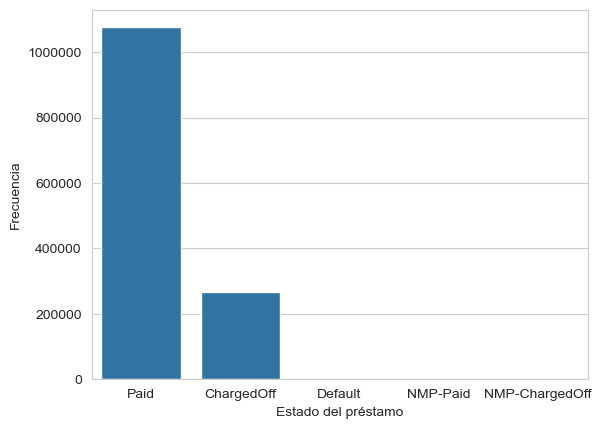

In [11]:
map_status = {
    "Fully Paid": "Paid",
    "Charged Off": "ChargedOff",
    "Default": "Default",
    "Does not meet the credit policy. Status:Fully Paid": "NMP-Paid",
    "Does not meet the credit policy. Status:Charged Off": "NMP-ChargedOff"
}

aceptado["loan_status"] = aceptado["loan_status"].replace(map_status)

aceptado = aceptado[
    aceptado["loan_status"].isin([
        "Paid",
        "ChargedOff",
        "Default",
        "NMP-Paid",
        "NMP-ChargedOff"
    ])
]


sns.countplot(x = "loan_status", data = aceptado)

plt.ticklabel_format(style='plain', axis='y')
plt.xlabel("Estado del préstamo")
plt.ylabel("Frecuencia")

In [12]:
missing_table = pd.DataFrame({
    "Valores Faltantes": aceptado.isnull().sum(),
    "Porcentaje": aceptado.isnull().mean() * 100
})

missing_table = missing_table.sort_values("Porcentaje", ascending=False)

missing_table

,Valores Faltantes,Porcentaje
loan_amnt,0,0.0
revol_bal,0,0.0
chargeoff_within_12_mths,0,0.0
acc_now_delinq,0,0.0
collections_12_mths_ex_med,0,0.0
pub_rec,0,0.0
delinq_2yrs,0,0.0
inq_last_6mths,0,0.0
earliest_cr_line,0,0.0
fico_range_high,0,0.0


La unica variable con un porcentaje mayor al 5% es emp_length por lo que podemos imputar esta variable por métodos sencillos de imputación. Para el resto de variables, no resulta necesario la imputación pues su porcentaje de valores faltantes es menor al 5%, por lo que podemos eliminar dichos registros

### Distribución

#### Préstamos

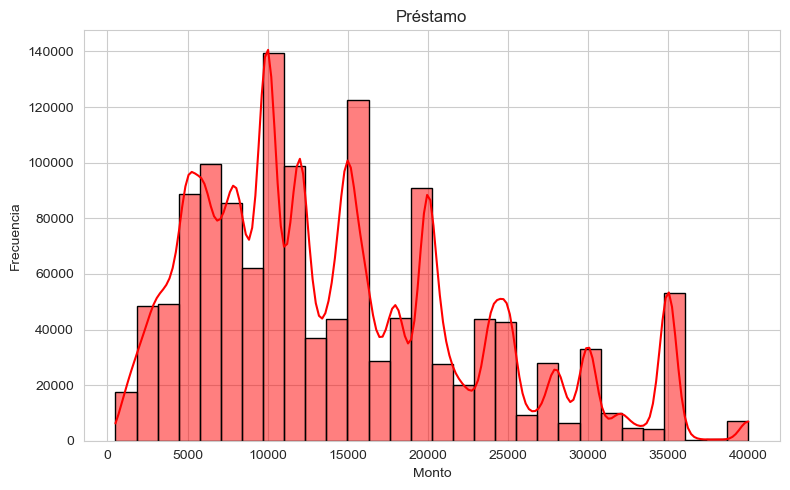

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(
    aceptado["loan_amnt"],
    bins=30,
    kde = True,
    color="red",
    edgecolor="black"
)
plt.title("Préstamo")
plt.xlabel("Monto")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

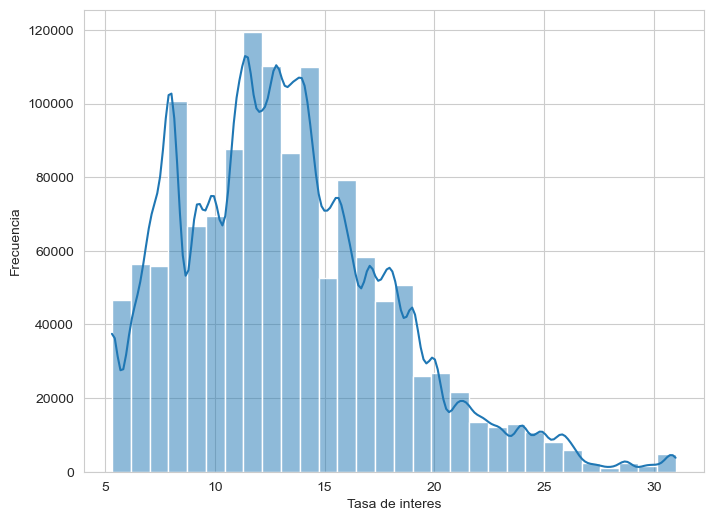

In [14]:
plt.figure(figsize=(8,6))
sns.histplot(aceptado["int_rate"],
            bins = 30,
            kde = True)
plt.xlabel("Tasa de interes")
plt.ylabel("Frecuencia")
plt.show()

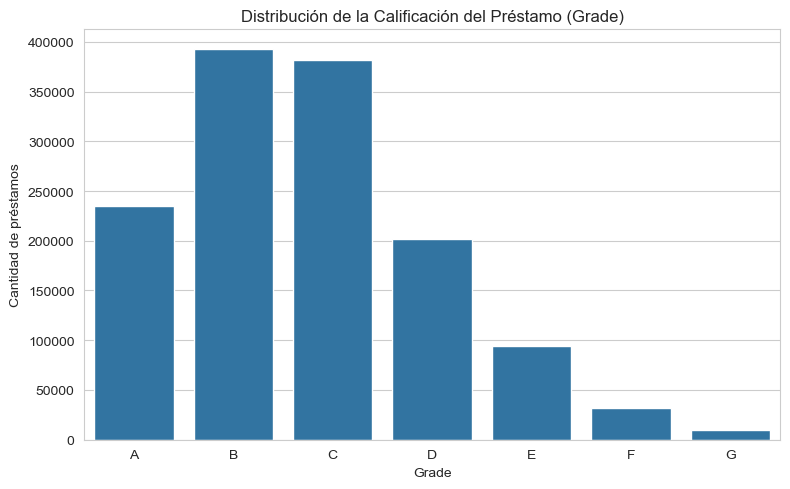

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x="grade",
    data=aceptado,
    order=sorted(aceptado["grade"].unique())
)

plt.title("Distribución de la Calificación del Préstamo (Grade)")
plt.xlabel("Grade")
plt.ylabel("Cantidad de préstamos")

plt.ticklabel_format(style="plain", axis="y")

plt.tight_layout()
plt.show()


#### Perfil económico del prestatario

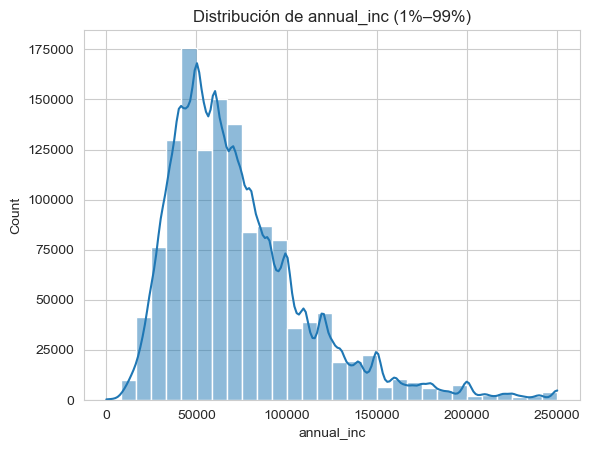

In [16]:
i = aceptado["annual_inc"]

p99 = i.quantile(0.99)

sns.histplot(i[i.between(0,p99)], bins=30, kde= True)

plt.ticklabel_format(style="plain", axis="both",)
plt.title("Distribución de annual_inc (1%–99%)")
plt.show()

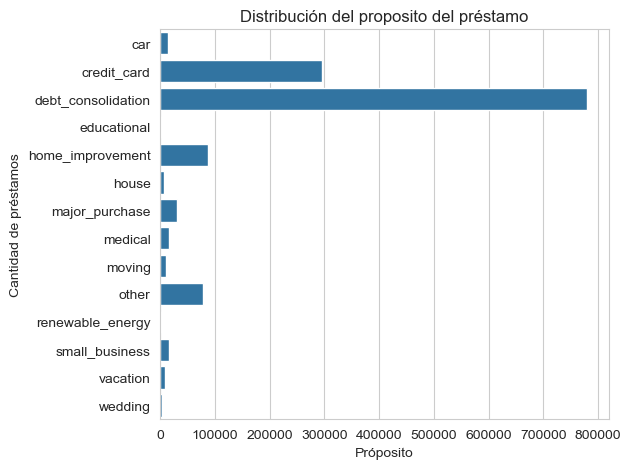

In [17]:
sns.countplot(y = aceptado["purpose"], order=sorted(aceptado["purpose"].unique()))
plt.title("Distribución del proposito del préstamo")
plt.xlabel("Próposito")
plt.ylabel("Cantidad de préstamos")
plt.tight_layout()
plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_29172\1582950712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


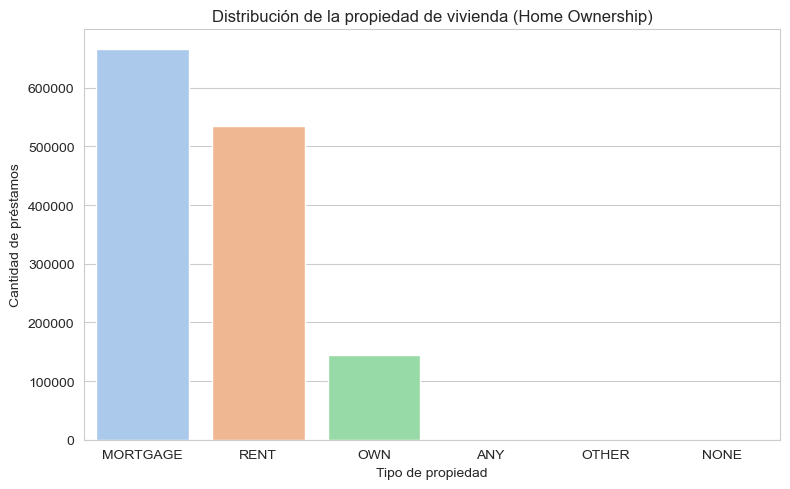

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="home_ownership",
    data=aceptado,
    order=aceptado["home_ownership"].value_counts().index,  # orden por frecuencia
    palette="pastel"
)

plt.title("Distribución de la propiedad de vivienda (Home Ownership)")
plt.xlabel("Tipo de propiedad")
plt.ylabel("Cantidad de préstamos")
plt.ticklabel_format(style="plain", axis="y")  # evita notación científica

plt.tight_layout()
plt.show()

#### Riesgo crediticio

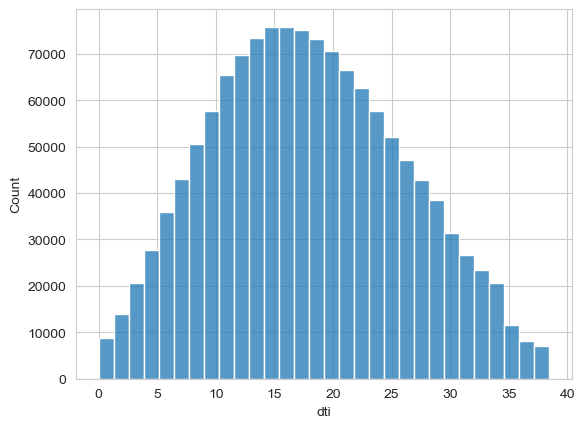

In [19]:
i1 = aceptado["dti"]

p99 = i1.quantile(0.99)

sns.histplot(i1[i1.between(0, p99)], bins=30)
plt.ticklabel_format(style="plain")
plt.show()

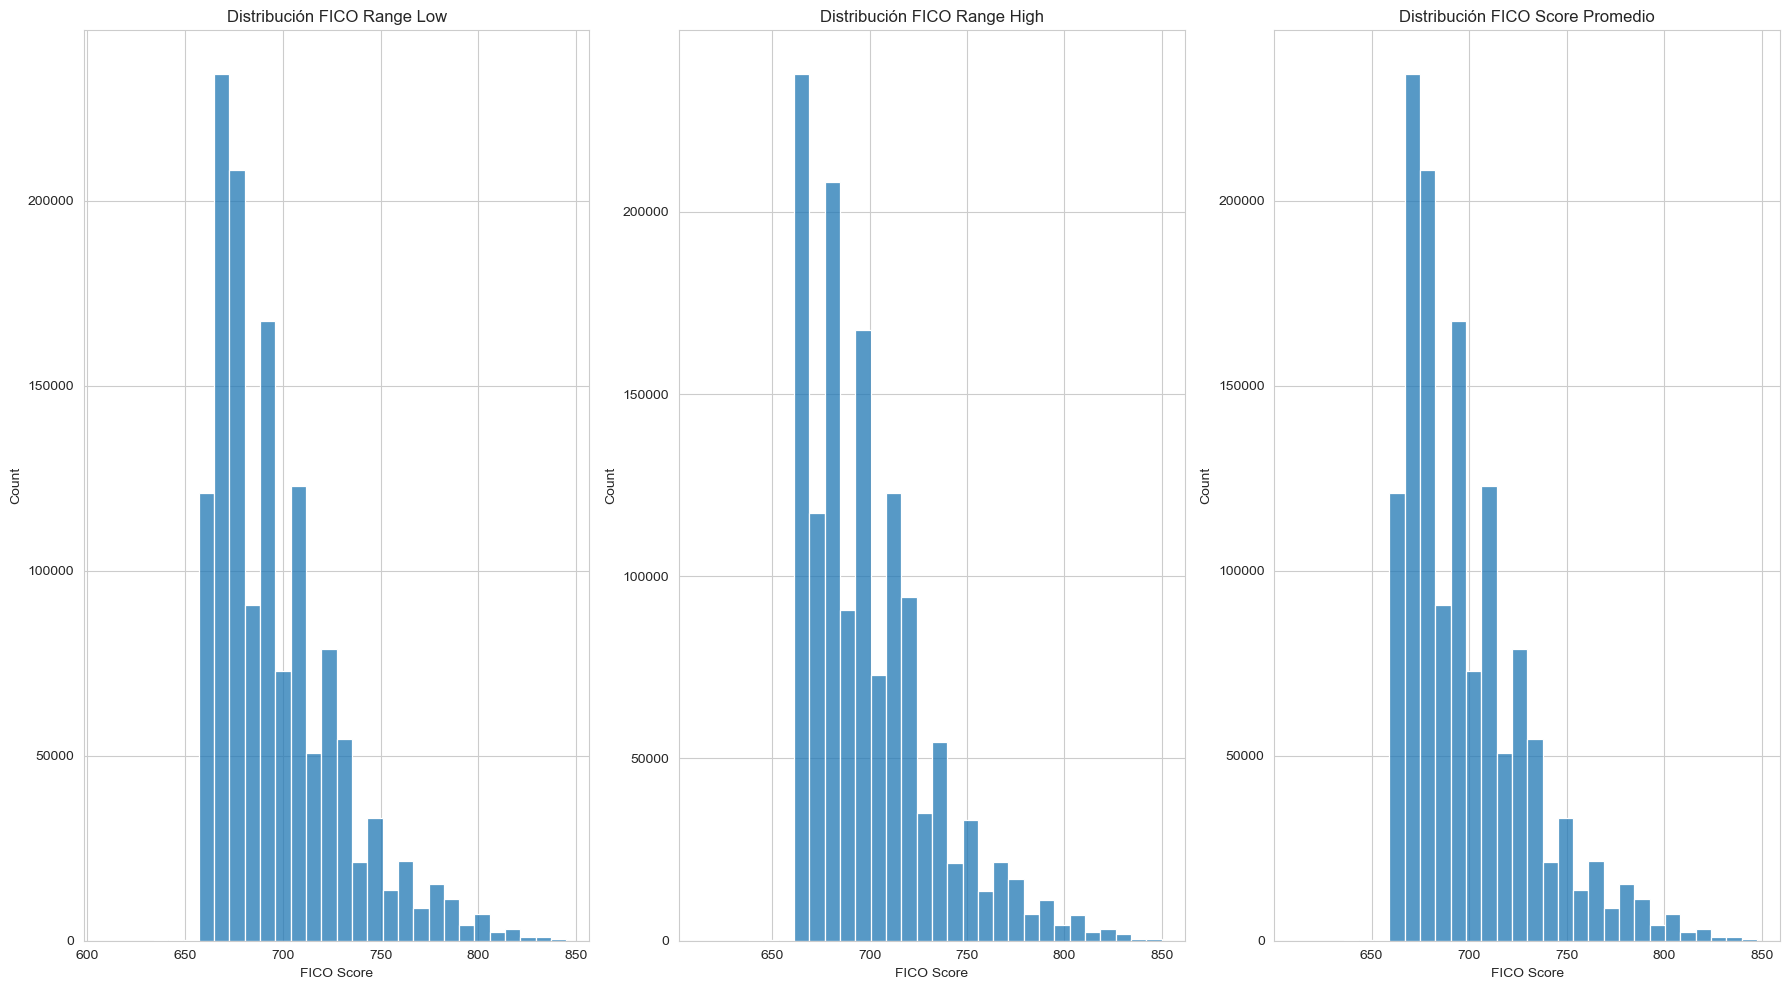

In [20]:
aceptado["fico_score"] = (
    aceptado["fico_range_low"] + aceptado["fico_range_high"]
) / 2
# FICO rango inferior

fig, axes = plt.subplots(1, 3, figsize=(18,10))
sns.histplot(aceptado["fico_range_low"],bins= 30, ax=axes[0])
axes[0].set_title("Distribución FICO Range Low")
axes[0].set_xlabel("FICO Score")

# FICO rango superior
sns.histplot(aceptado["fico_range_high"],bins= 30, ax=axes[1])
axes[1].set_title("Distribución FICO Range High")
axes[1].set_xlabel("FICO Score")

# FICO promedio
sns.histplot(aceptado["fico_score"], bins= 30, ax=axes[2])
axes[2].set_title("Distribución FICO Score Promedio")
axes[2].set_xlabel("FICO Score")

plt.tight_layout()
plt.show()

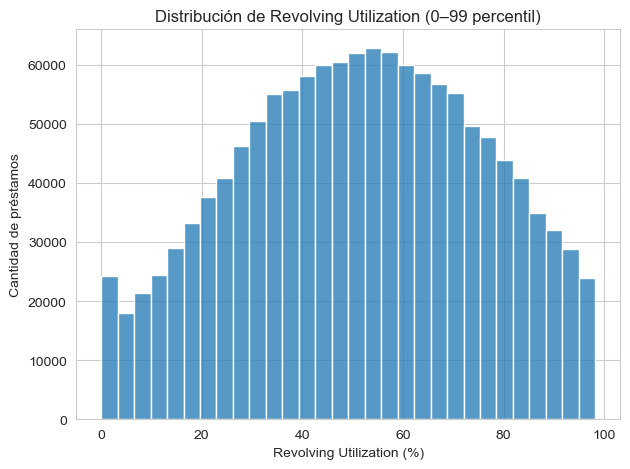

In [21]:
i0 = aceptado["revol_util"]
p099= i0.quantile(0.99)
sns.histplot(i0[i0.between(0, p099)], bins=30)

plt.xlabel("Revolving Utilization (%)")  # etiqueta del eje x
plt.ylabel("Cantidad de préstamos")      # etiqueta del eje y
plt.title("Distribución de Revolving Utilization (0–99 percentil)")

plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()



### Relación con el estado del préstamo

In [22]:
import pandas as pd

# Crear la nueva columna con las 3 categorías
aceptado["target"] = aceptado["loan_status"].replace({
    "Paid": "Pagado",
    "NMP-Paid": "Pagado",
    "ChargedOff": "Incumplimiento",
    "NMP-ChargedOff": "Incumplimiento",
    "Default": "Incumplimiento"
})

# Verificar el conteo de cada categoría
conteo = aceptado["target"].value_counts()
print(conteo)

target
Pagado            1077635
Incumplimiento     269080
Name: count, dtype: int64


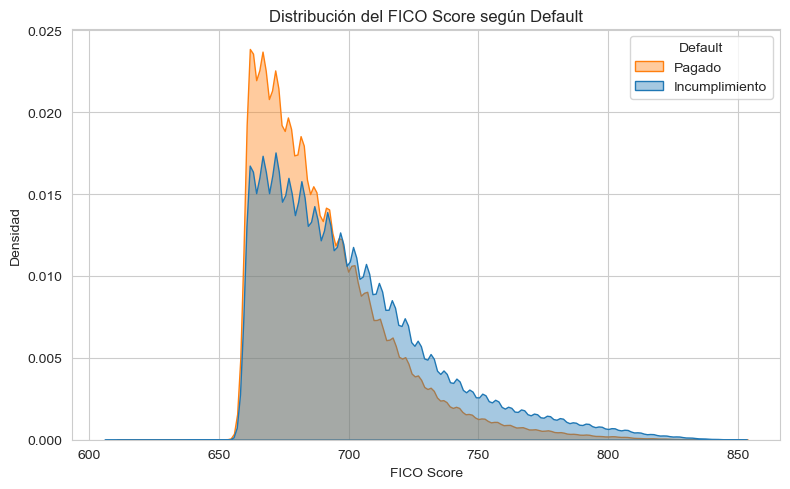

In [23]:

plt.figure(figsize=(8,5))

sns.kdeplot(
    data=aceptado,
    x="fico_score",
    hue="target",
    common_norm= False,
    fill=True,
    alpha=0.4
)

plt.ticklabel_format(style="plain", axis="y")
plt.title("Distribución del FICO Score según Default")
plt.xlabel("FICO Score")
plt.ylabel("Densidad")
plt.legend(title="Default", labels=["Pagado", "Incumplimiento"])
plt.tight_layout()
plt.show()

   - fico vs default
   - dti vs default
   - grade vs default

<Axes: xlabel='dti', ylabel='Density'>

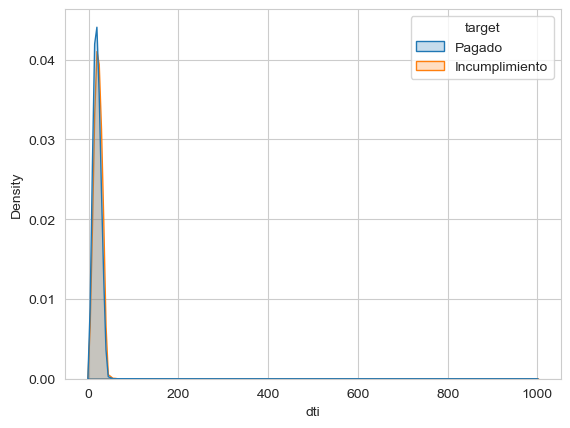

In [24]:
sns.kdeplot(x="dti", hue="target", data= aceptado, common_norm= False, fill=True)

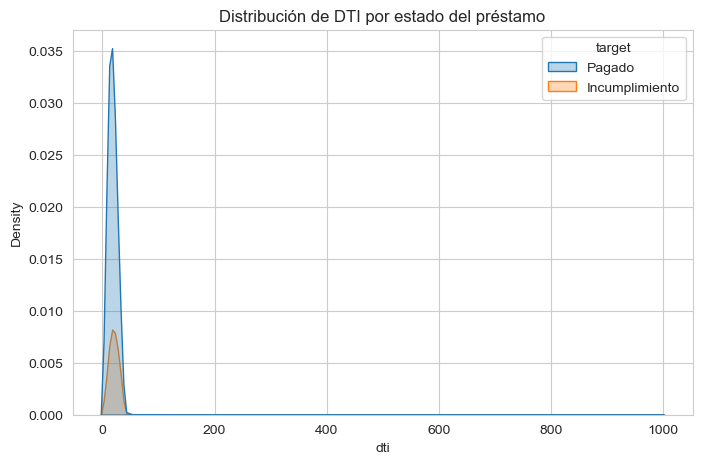

In [25]:
plt.figure(figsize=(8,5))
sns.kdeplot(data=aceptado, x="dti", hue="target", fill=True, alpha=0.3)
plt.title("Distribución de DTI por estado del préstamo")
plt.show()

C:\Users\camil\AppData\Local\Temp\ipykernel_29172\4222504838.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


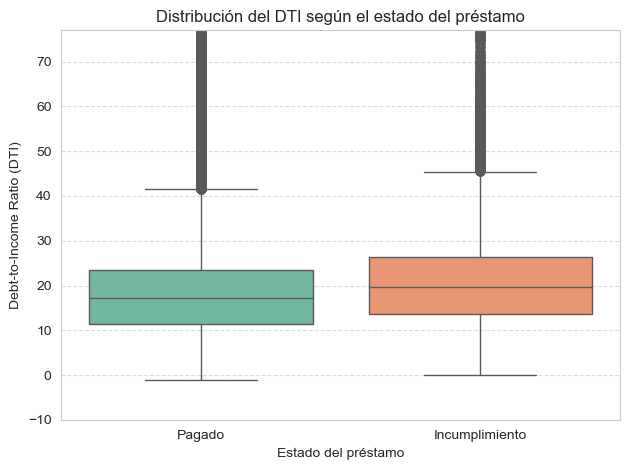

In [26]:
p99 = aceptado["dti"].quantile(0.99)


sns.boxplot(
    x="target",
    y="dti",
    data=aceptado,
    palette="Set2"
)

plt.title("Distribución del DTI según el estado del préstamo")
plt.xlabel("Estado del préstamo")
plt.ylabel("Debt-to-Income Ratio (DTI)")
plt.ylim(-10, p99*2)  # ajusta un poco arriba para que no corte el bigote
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

<Axes: xlabel='grade', ylabel='count'>

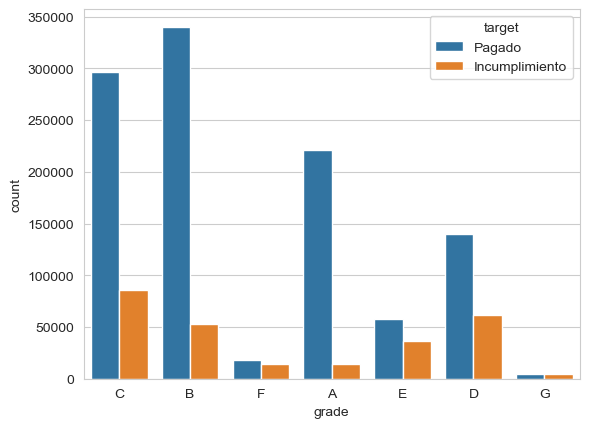

In [27]:
aceptado["grade"].unique()
sns.countplot(x="grade", hue="target", data=aceptado)

## Correlación y multicolinealidad

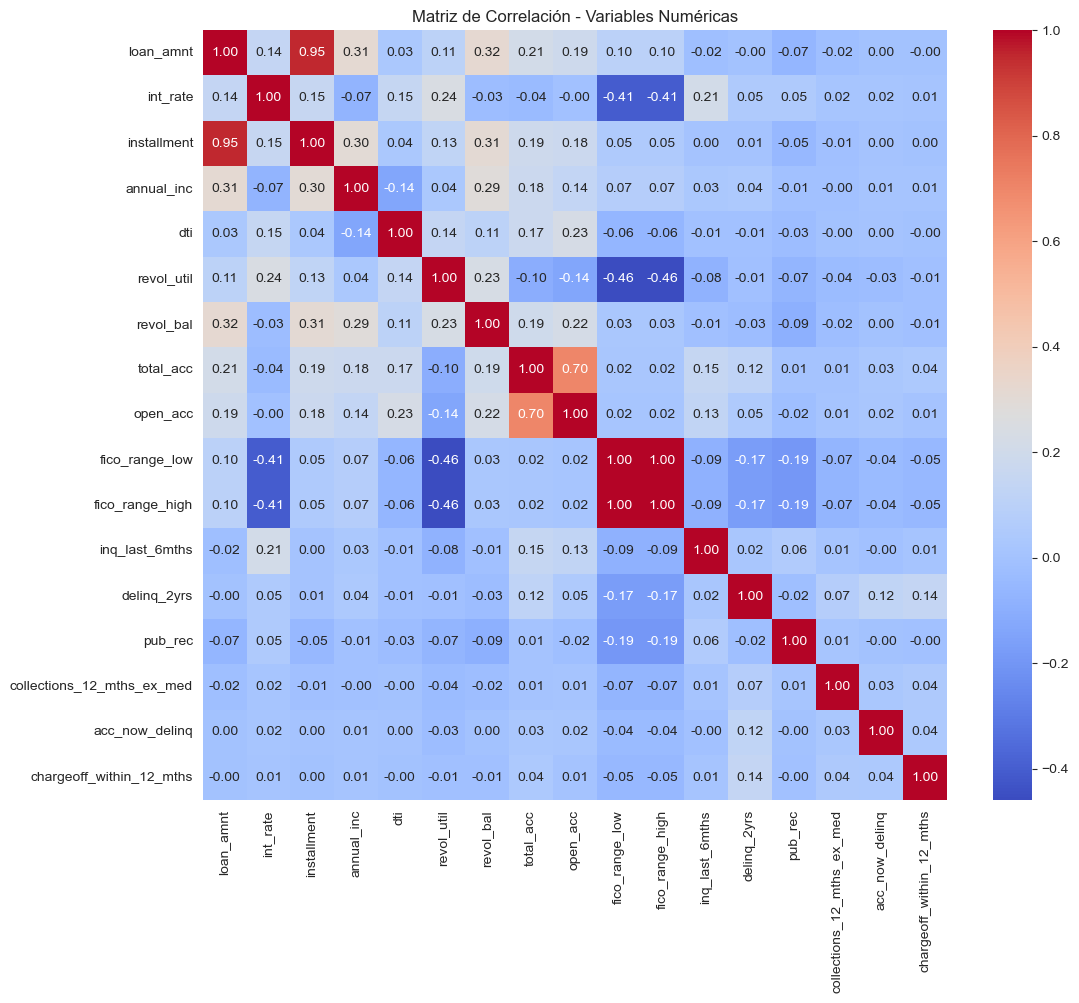

In [28]:

num_vars = [
    "loan_amnt", "int_rate", "installment", "annual_inc", "dti",
    "revol_util", "revol_bal", "total_acc", "open_acc",
    "fico_range_low", "fico_range_high",
    "inq_last_6mths", "delinq_2yrs", "pub_rec",
    "collections_12_mths_ex_med", "acc_now_delinq", "chargeoff_within_12_mths"
]

df_num = aceptado[num_vars]

corr_matrix = df_num.corr()

# Plot
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

In [29]:
# ------------------------------
# Pipeline profesional completo
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

# Copiar dataset
aceptado = aceptado.copy()

# ------------------------------
# 1️⃣ Variables derivadas
# ------------------------------
aceptado['fico_mean'] = (aceptado['fico_range_low'] + aceptado['fico_range_high']) / 2
aceptado['debt_ratio'] = aceptado['installment'] / (aceptado['annual_inc']/12)
aceptado['high_dti'] = (aceptado['dti'] > 40).astype(int)

# Emp_length robusta
def emp_to_int(emp):
    if pd.isna(emp) or str(emp).lower() == 'unknown':
        return 0
    emp = str(emp).strip()
    if emp == '< 1 year':
        return 0
    if emp == '10+ years':
        return 10
    try:
        return int(emp.split()[0])
    except:
        return 0

aceptado['emp_length_num'] = aceptado['emp_length'].apply(emp_to_int)



# ------------------------------
# 2️⃣ Definir variables
# ------------------------------
num_features = [
    'loan_amnt', 'int_rate', 'installment', 'annual_inc', 
    'dti', 'revol_util', 'revol_bal', 'fico_mean', 'debt_ratio',
    'emp_length_num'
]

# Variables con outliers para log-transform
num_features_log = ['loan_amnt', 'annual_inc', 'revol_bal']

cat_ordinal = ['grade', 'sub_grade']
cat_nominal = ['purpose', 'home_ownership', 'verification_status', 'addr_state']
num_features_passthrough = [f for f in num_features if f not in num_features_log]








# Orden para ordinal
grade_order = ['A','B','C','D','E','F','G']
subgrade_order = [f"{g}{i}" for g in grade_order for i in range(1,6)]

# ------------------------------
# 3️⃣ Transformadores
# ------------------------------

# Log-transform para variables con outliers
log_transformer = FunctionTransformer(np.log1p, validate=True)

from sklearn.compose import make_column_selector

num_transformer = ColumnTransformer([
    ('log', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, validate=False)),
        ('scaler', StandardScaler())
    ]), num_features_log),
    
    ('passthrough', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_features_passthrough)
])
cat_ordinal_transformer = Pipeline(steps=[
    ('ordinal', OrdinalEncoder(categories=[grade_order, subgrade_order]))
])

cat_nominal_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ------------------------------
# 4️⃣ ColumnTransformer
# ------------------------------
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('ord', cat_ordinal_transformer, cat_ordinal),
    ('nom', cat_nominal_transformer, cat_nominal)
])

# ------------------------------
# 5️⃣ Pipeline completo con modelo
# ------------------------------
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])



In [30]:
# ------------------------------
# 6️⃣ División entrenamiento / prueba
# ------------------------------
X = aceptado[num_features + cat_ordinal + cat_nominal]
y = aceptado['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# 7️⃣ Pipeline con Logistic Regression
# ------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

# Reemplazar el clasificador por LogisticRegression
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # tu preprocesador actual
    ('classifier', LogisticRegression(
        max_iter=1000,      # asegurar convergencia
        solver='saga',      # rápido para muchas columnas
        n_jobs=-1,          # usar todos los núcleos
        random_state=42
    ))
])

# ------------------------------
# 8️⃣ Entrenar y evaluar
# ------------------------------
model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

c:\Users\camil\anaconda3\envs\mlp\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


                precision    recall  f1-score   support

Incumplimiento       0.52      0.07      0.13     53816
        Pagado       0.81      0.98      0.89    215527

      accuracy                           0.80    269343
     macro avg       0.67      0.53      0.51    269343
  weighted avg       0.75      0.80      0.74    269343

ROC AUC: 0.7067336518994096


In [31]:

np.isnan(aceptado[num_features]).sum()  # cuántos NaN por columna

loan_amnt         0
int_rate          0
installment       0
annual_inc        0
dti               0
revol_util        0
revol_bal         0
fico_mean         0
debt_ratio        0
emp_length_num    0
dtype: int64